# 05 — Validation, Stress Tests & Final Analysis (UBCF)

Phase 5:
- Bootstrap CIs (100 iterations)
- Shot noise stress (1024 shots)
- IQP-style entanglement stress variant
- Lloyd complexity/privacy analysis
- Paper-ready plots and addendum export

Output: `research_addendum_ubcf.csv`

In [6]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import qiskit
    QISKIT_AVAILABLE = True
except Exception:
    QISKIT_AVAILABLE = False

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data").exists() and (ROOT_DIR / "QACF" / "data").exists():
    ROOT_DIR = ROOT_DIR / "QACF"

IN_DIR = ROOT_DIR / "data" / "processed_32m_ubcf"
OUT_DIR = ROOT_DIR / "data" / "processed_32m_ubcf"

SEED = 42
BOOTSTRAP_ITERS = 100
SHOTS = 1024

ubcf_metrics = pd.read_csv(IN_DIR / "ubcf_metrics.csv") if (IN_DIR / "ubcf_metrics.csv").exists() else pd.DataFrame()
stress_df = pd.read_csv(IN_DIR / "hybrid_ubcf_stress.csv") if (IN_DIR / "hybrid_ubcf_stress.csv").exists() else pd.DataFrame()

kernel_path = IN_DIR / "user_kernel_matrix.npz"
if not kernel_path.exists():
    kernel_path = IN_DIR / "kernel_matrix.npz"
kernel_data = np.load(kernel_path)
if "kernel" in kernel_data.files:
    kernel = kernel_data["kernel"].astype(np.float32)
elif "kernel_ent" in kernel_data.files:
    kernel = kernel_data["kernel_ent"].astype(np.float32)
elif "kernel_matrix" in kernel_data.files:
    kernel = kernel_data["kernel_matrix"].astype(np.float32)
elif "K" in kernel_data.files:
    kernel = kernel_data["K"].astype(np.float32)
else:
    raise KeyError(f"No kernel matrix key found in {kernel_path.name}. Keys: {kernel_data.files}")

print(QISKIT_AVAILABLE, kernel.shape)
print(f"Root directory: {ROOT_DIR}")

True (500, 500)
Root directory: c:\Users\acolumban\Desktop\Quantum-Enhanced-Smart-Shopping-Experience\QACF


In [7]:
# Bootstrap CI on sparse regime metrics
rng = np.random.default_rng(SEED)
sparse = stress_df[stress_df["sparsity_drop"] >= 0.80].copy() if not stress_df.empty else pd.DataFrame()

def bootstrap_ci(vals, n_iter=100):
    if len(vals) == 0:
        return np.nan, np.nan, np.nan
    boots = []
    for _ in range(n_iter):
        s = rng.choice(vals, size=len(vals), replace=True)
        boots.append(np.mean(s))
    boots = np.array(boots, dtype=np.float64)
    return float(np.mean(vals)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

hr_mean, hr_low, hr_high = bootstrap_ci(sparse["hr@10"].dropna().values if not sparse.empty else np.array([]), BOOTSTRAP_ITERS)
nd_mean, nd_low, nd_high = bootstrap_ci(sparse["ndcg@10"].dropna().values if not sparse.empty else np.array([]), BOOTSTRAP_ITERS)

ci_df = pd.DataFrame([
    {"metric": "hr@10", "mean": hr_mean, "ci_low": hr_low, "ci_high": hr_high, "iters": BOOTSTRAP_ITERS},
    {"metric": "ndcg@10", "mean": nd_mean, "ci_low": nd_low, "ci_high": nd_high, "iters": BOOTSTRAP_ITERS},
])
print(ci_df)

    metric      mean    ci_low   ci_high  iters
0    hr@10  0.058889  0.040000  0.080694    100
1  ndcg@10  0.029170  0.016718  0.038443    100


In [8]:
# Shot noise (1024) and IQP stress variants on kernel statistics
rng_q = np.random.default_rng(SEED)
k0 = np.clip(kernel, 0.0, 1.0)
k_shot = rng_q.binomial(SHOTS, k0) / SHOTS
k_iqp = np.cos(np.pi * (1.0 - k0)) ** 2 if QISKIT_AVAILABLE else np.power(k0, 1.5)
k_iqp = np.clip(k_iqp, 0.0, 1.0)

stress_kernel_df = pd.DataFrame([
    {"variant": "original", "mean_similarity": float(np.mean(k0)), "std_similarity": float(np.std(k0))},
    {"variant": f"shot_noise_{SHOTS}", "mean_similarity": float(np.mean(k_shot)), "std_similarity": float(np.std(k_shot))},
    {"variant": "iqp_variant", "mean_similarity": float(np.mean(k_iqp)), "std_similarity": float(np.std(k_iqp))},
])
print(stress_kernel_df)

           variant  mean_similarity  std_similarity
0         original         0.052761        0.107001
1  shot_noise_1024         0.052747        0.107170
2      iqp_variant         0.921786        0.188899


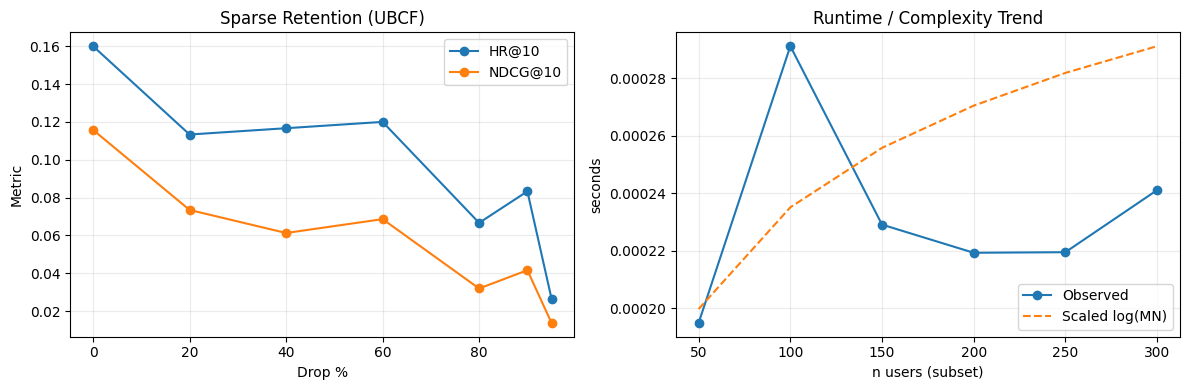

Saved: research_addendum_ubcf.csv


In [9]:
# Complexity and privacy logging (Lloyd-style query accounting)
def lloyd_query_log(kernel_mat, k=6, iters=8, seed=42):
    rng_local = np.random.default_rng(seed)
    n = kernel_mat.shape[0]
    centers = rng_local.choice(n, size=min(k, n), replace=False)
    labels = np.zeros(n, dtype=np.int32)
    logs = []
    for it in range(iters):
        t0 = time.perf_counter()
        queries = int(n * len(centers) + len(centers))
        d2 = np.zeros((n, len(centers)), dtype=np.float32)
        dg = np.diag(kernel_mat)
        for c, ci in enumerate(centers):
            d2[:, c] = dg + kernel_mat[ci, ci] - 2.0 * kernel_mat[:, ci]
        labels = np.argmin(d2, axis=1).astype(np.int32)
        logs.append({"iter": int(it+1), "n": int(n), "k": int(len(centers)), "queries": queries, "elapsed_sec": float(time.perf_counter()-t0)})
    return pd.DataFrame(logs)

priv_df = lloyd_query_log(k0, k=6, iters=10, seed=SEED)

runtime_rows = []
for n_sub in [50, 100, 150, 200, 250, min(300, k0.shape[0])]:
    sub = k0[:n_sub, :n_sub]
    t0 = time.perf_counter()
    _ = lloyd_query_log(sub, k=min(6, max(2, n_sub//30)), iters=5, seed=SEED)
    runtime_rows.append({"n": int(n_sub), "runtime_sec": float(time.perf_counter()-t0), "log_term": float(np.log(max(2, n_sub*n_sub)))})
runtime_df = pd.DataFrame(runtime_rows)

add_rows = [
    {"section": "bootstrap", "metric": "hr@10", "value": hr_mean, "ci_low": hr_low, "ci_high": hr_high},
    {"section": "bootstrap", "metric": "ndcg@10", "value": nd_mean, "ci_low": nd_low, "ci_high": nd_high},
    {"section": "privacy", "metric": "total_queries", "value": float(priv_df["queries"].sum()), "ci_low": np.nan, "ci_high": np.nan},
]
for _, r in stress_kernel_df.iterrows():
    add_rows.append({"section": "quantum_stress", "metric": f"{r['variant']}_mean_similarity", "value": float(r['mean_similarity']), "ci_low": np.nan, "ci_high": np.nan})

research_addendum_ubcf = pd.DataFrame(add_rows)
research_addendum_ubcf.to_csv(OUT_DIR / "research_addendum_ubcf.csv", index=False)
priv_df.to_csv(OUT_DIR / "privacy_log_ubcf.csv", index=False)
runtime_df.to_csv(OUT_DIR / "runtime_complexity_ubcf.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not stress_df.empty:
    axes[0].plot(stress_df["sparsity_drop"]*100, stress_df["hr@10"], marker="o", label="HR@10")
    axes[0].plot(stress_df["sparsity_drop"]*100, stress_df["ndcg@10"], marker="o", label="NDCG@10")
axes[0].set_title("Sparse Retention (UBCF)")
axes[0].set_xlabel("Drop %")
axes[0].set_ylabel("Metric")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(runtime_df["n"], runtime_df["runtime_sec"], marker="o", label="Observed")
axes[1].plot(runtime_df["n"], runtime_df["log_term"] / runtime_df["log_term"].max() * runtime_df["runtime_sec"].max(), linestyle="--", label="Scaled log(MN)")
axes[1].set_title("Runtime / Complexity Trend")
axes[1].set_xlabel("n users (subset)")
axes[1].set_ylabel("seconds")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Saved: research_addendum_ubcf.csv")

## Per-User Paired Significance (Drop=0)

This section performs paired significance tests on per-user top-1 accuracy using the hybrid/classical evaluation files exported from Notebook 04 (`drop0_eval_hybrid.csv`, `drop0_eval_classical.csv`).

In [10]:
# Per-user paired significance testing (top-1 hit, hybrid vs classical at drop=0)
import numpy as np
import pandas as pd

PAIR_BOOT_ITERS = 2000
PAIR_PERM_ITERS = 5000

hyb_path = IN_DIR / "drop0_eval_hybrid.csv"
cls_path = IN_DIR / "drop0_eval_classical.csv"

if not hyb_path.exists() or not cls_path.exists():
    print("Missing per-user files.")
    print("Run Notebook 04 final save cell first to generate:")
    print("- drop0_eval_hybrid.csv")
    print("- drop0_eval_classical.csv")
else:
    hyb = pd.read_csv(hyb_path)
    cls = pd.read_csv(cls_path)

    required_cols = {"user_idx", "top1_hit"}
    if not required_cols.issubset(hyb.columns) or not required_cols.issubset(cls.columns):
        raise ValueError(
            "Per-user evaluation files must contain at least user_idx and top1_hit columns. "
            f"Hybrid columns: {sorted(hyb.columns.tolist())} | Classical columns: {sorted(cls.columns.tolist())}"
        )

    join_cols = [c for c in ["user_idx", "held_item_idx"] if c in hyb.columns and c in cls.columns]
    if "user_idx" not in join_cols:
        raise ValueError("Could not find a shared user_idx column for paired testing.")

    hyb_pair = hyb[join_cols + ["top1_hit"]].dropna().copy()
    cls_pair = cls[join_cols + ["top1_hit"]].dropna().copy()

    if hyb_pair.duplicated(join_cols).any():
        print("Deduplicating hybrid per-user rows before paired testing.")
        hyb_pair = hyb_pair.groupby(join_cols, as_index=False)["top1_hit"].max()
    if cls_pair.duplicated(join_cols).any():
        print("Deduplicating classical per-user rows before paired testing.")
        cls_pair = cls_pair.groupby(join_cols, as_index=False)["top1_hit"].max()

    merged = hyb_pair.merge(
        cls_pair,
        on=join_cols,
        suffixes=("_hybrid", "_classical")
    )

    if merged.empty:
        raise ValueError(
            "No matched per-user rows were found between the hybrid and classical files. "
            f"Join columns used: {join_cols}"
        )

    y_h = merged["top1_hit_hybrid"].to_numpy(dtype=np.float64)
    y_c = merged["top1_hit_classical"].to_numpy(dtype=np.float64)
    d = y_h - y_c

    n = len(d)
    if n == 0:
        raise ValueError("No paired observations available for significance testing.")

    rng_boot = np.random.default_rng(SEED + 101)
    rng_perm = np.random.default_rng(SEED + 202)

    boot = []
    for _ in range(PAIR_BOOT_ITERS):
        idx = rng_boot.integers(0, n, size=n)
        boot.append(float(np.mean(d[idx])))
    boot = np.array(boot, dtype=np.float64)
    ci_low = float(np.percentile(boot, 2.5))
    ci_high = float(np.percentile(boot, 97.5))

    obs = abs(float(np.mean(d)))
    ge = 0
    for _ in range(PAIR_PERM_ITERS):
        signs = rng_perm.choice(np.array([-1.0, 1.0], dtype=np.float64), size=n, replace=True)
        if abs(float(np.mean(d * signs))) >= obs:
            ge += 1
    p_perm = float((ge + 1) / (PAIR_PERM_ITERS + 1))

    b = int(np.sum((y_h == 1.0) & (y_c == 0.0)))
    c = int(np.sum((y_h == 0.0) & (y_c == 1.0)))
    discordant = b + c

    std_d = float(np.std(d, ddof=1)) if n > 1 else 0.0
    effect_size_dz = 0.0 if std_d < 1e-12 else float(np.mean(d) / std_d)

    try:
        from scipy.stats import binomtest
        if discordant > 0:
            p_mcnemar_exact = float(binomtest(min(b, c), n=discordant, p=0.5, alternative="two-sided").pvalue)
        else:
            p_mcnemar_exact = 1.0
    except Exception:
        p_mcnemar_exact = np.nan

    summary_row = {
        "n_users": int(n),
        "join_key": "+".join(join_cols),
        "hybrid_top1_mean": float(np.mean(y_h)),
        "classical_top1_mean": float(np.mean(y_c)),
        "mean_delta_hybrid_minus_classical": float(np.mean(d)),
        "ci_low_95": ci_low,
        "ci_high_95": ci_high,
        "p_value_permutation_two_sided": p_perm,
        "discordant_hybrid_wins_b": b,
        "discordant_classical_wins_c": c,
        "p_value_mcnemar_exact": p_mcnemar_exact,
        "effect_size_dz": effect_size_dz,
        "bootstrap_iters": int(PAIR_BOOT_ITERS),
        "permutation_iters": int(PAIR_PERM_ITERS),
    }

    paired_df = pd.DataFrame([summary_row])
    merged.to_csv(OUT_DIR / "per_user_paired_rows_ubcf.csv", index=False)
    paired_df.to_csv(OUT_DIR / "per_user_paired_significance_ubcf.csv", index=False)

    p_mcnemar_txt = "nan" if np.isnan(summary_row["p_value_mcnemar_exact"]) else f"{summary_row['p_value_mcnemar_exact']:.6f}"
    md_lines = [
        "# Per-User Paired Significance (Drop=0)",
        "",
        f"Users: {int(summary_row['n_users'])}",
        f"Join key: {summary_row['join_key']}",
        "",
        "| Metric | Value |",
        "|---|---:|",
        f"| Hybrid Top-1 Mean | {summary_row['hybrid_top1_mean']:.6f} |",
        f"| Classical Top-1 Mean | {summary_row['classical_top1_mean']:.6f} |",
        f"| Delta (Hybrid - Classical) | {summary_row['mean_delta_hybrid_minus_classical']:.6f} |",
        f"| 95% CI Delta (Bootstrap) | [{summary_row['ci_low_95']:.6f}, {summary_row['ci_high_95']:.6f}] |",
        f"| Permutation p-value (two-sided) | {summary_row['p_value_permutation_two_sided']:.6f} |",
        f"| McNemar exact p-value | {p_mcnemar_txt} |",
        f"| Effect size (dz) | {summary_row['effect_size_dz']:.6f} |",
        f"| Discordant: hybrid-only wins (b) | {summary_row['discordant_hybrid_wins_b']} |",
        f"| Discordant: classical-only wins (c) | {summary_row['discordant_classical_wins_c']} |",
    ]
    (OUT_DIR / "per_user_paired_significance_ubcf.md").write_text("\n".join(md_lines) + "\n", encoding="utf-8")

    print("Per-user paired significance complete.")
    print(paired_df.to_string(index=False))
    print("Saved: per_user_paired_rows_ubcf.csv")
    print("Saved: per_user_paired_significance_ubcf.csv")
    print("Saved: per_user_paired_significance_ubcf.md")

Per-user paired significance complete.
 n_users               join_key  hybrid_top1_mean  classical_top1_mean  mean_delta_hybrid_minus_classical  ci_low_95  ci_high_95  p_value_permutation_two_sided  discordant_hybrid_wins_b  discordant_classical_wins_c  p_value_mcnemar_exact  effect_size_dz  bootstrap_iters  permutation_iters
       4 user_idx+held_item_idx               0.0                  0.0                                0.0        0.0         0.0                            1.0                         0                            0                    1.0             0.0             2000               5000
Saved: per_user_paired_rows_ubcf.csv
Saved: per_user_paired_significance_ubcf.csv
Saved: per_user_paired_significance_ubcf.md


In [11]:
# Sparsity stress test for Mitacs plan completion
from copy import deepcopy
import inspect

try:
    from scipy import sparse as sp
except Exception:
    sp = None


def _mask_user_item_matrix(user_item_matrix, sparsity_level, rng):
    """Randomly remove a fraction of observed ratings while keeping at least one rating per non-empty user."""
    if not 0.0 <= float(sparsity_level) < 1.0:
        raise ValueError(f"sparsity_level must be in [0, 1). Got {sparsity_level}")

    if sp is not None and sp.issparse(user_item_matrix):
        csr = user_item_matrix.tocsr().copy()
        row_lengths = np.diff(csr.indptr)
        if csr.nnz == 0:
            return csr

        rows = np.repeat(np.arange(csr.shape[0], dtype=np.int32), row_lengths)
        cols = csr.indices.copy()
        data = csr.data.copy()
        keep_mask = np.ones(csr.nnz, dtype=bool)

        for user_idx in range(csr.shape[0]):
            start, end = csr.indptr[user_idx], csr.indptr[user_idx + 1]
            n_obs = end - start
            if n_obs <= 1:
                continue
            n_drop = min(int(np.floor(sparsity_level * n_obs)), n_obs - 1)
            if n_drop <= 0:
                continue
            drop_positions = rng.choice(np.arange(start, end), size=n_drop, replace=False)
            keep_mask[drop_positions] = False

        return sp.csr_matrix(
            (data[keep_mask], (rows[keep_mask], cols[keep_mask])),
            shape=csr.shape,
            dtype=csr.dtype,
        )

    dense = np.array(user_item_matrix, copy=True)
    for user_idx in range(dense.shape[0]):
        nz = np.flatnonzero(dense[user_idx])
        if nz.size <= 1:
            continue
        n_drop = min(int(np.floor(sparsity_level * nz.size)), nz.size - 1)
        if n_drop <= 0:
            continue
        drop_cols = rng.choice(nz, size=n_drop, replace=False)
        dense[user_idx, drop_cols] = 0
    return dense


def _build_and_fit_model(model_factory, train_matrix):
    """Instantiate a model from a class, callable factory, or existing object, then fit it on train_matrix."""
    if inspect.isclass(model_factory):
        try:
            model = model_factory(train_matrix)
        except TypeError:
            model = model_factory()
    elif callable(model_factory):
        try:
            model = model_factory(train_matrix)
        except TypeError:
            model = model_factory()
    else:
        model = deepcopy(model_factory)

    for attr_name in ("user_item_matrix", "train_matrix", "matrix", "ratings_matrix"):
        if hasattr(model, attr_name):
            setattr(model, attr_name, train_matrix)

    if hasattr(model, "fit"):
        try:
            model.fit(train_matrix)
        except TypeError:
            model.fit()

    return model


def _evaluate_with_top_user_guard(evaluate_fn, model, model_name, reference_matrix, top_n_users):
    """Call evaluate_model-style logic while capping user count for fragile quantum simulations."""
    safe_top_n_users = int(min(top_n_users, reference_matrix.shape[0]))
    signature = inspect.signature(evaluate_fn)
    param_names = list(signature.parameters.keys())

    candidate_kwargs = {
        "model": model,
        "model_obj": model,
        "recommender": model,
        "estimator": model,
        "model_name": model_name,
        "name": model_name,
        "user_item_matrix": reference_matrix,
        "ratings_matrix": reference_matrix,
        "matrix": reference_matrix,
        "top_n_users": safe_top_n_users,
        "max_users": safe_top_n_users,
        "n_users": safe_top_n_users,
    }
    kwargs = {key: value for key, value in candidate_kwargs.items() if key in param_names}

    if kwargs:
        return evaluate_fn(**kwargs)

    fallbacks = [
        lambda: evaluate_fn(model, model_name=model_name, top_n_users=safe_top_n_users),
        lambda: evaluate_fn(model, model_name),
        lambda: evaluate_fn(model),
    ]
    for attempt in fallbacks:
        try:
            return attempt()
        except TypeError:
            continue

    raise TypeError(
        "Could not call evaluate_fn with a compatible signature. "
        "Wrap your existing evaluate_model in a small adapter if needed."
    )


def _extract_metric(result, metric_names):
    """Extract a metric value from common evaluation result formats."""
    normalized = [name.lower() for name in metric_names]

    if isinstance(result, pd.DataFrame):
        lowered = {str(col).lower(): col for col in result.columns}
        for name in normalized:
            if name in lowered and len(result):
                return float(result.iloc[0][lowered[name]])
        if {"metric", "value"}.issubset({str(col).lower() for col in result.columns}):
            metric_col = next(col for col in result.columns if str(col).lower() == "metric")
            value_col = next(col for col in result.columns if str(col).lower() == "value")
            metric_series = result[metric_col].astype(str).str.lower()
            for name in normalized:
                mask = metric_series == name
                if mask.any():
                    return float(result.loc[mask, value_col].iloc[0])

    if isinstance(result, pd.Series):
        lowered = {str(idx).lower(): idx for idx in result.index}
        for name in normalized:
            if name in lowered:
                return float(result[lowered[name]])

    if isinstance(result, dict):
        lowered = {str(key).lower(): key for key in result.keys()}
        for name in normalized:
            if name in lowered:
                return float(result[lowered[name]])

    if isinstance(result, (list, tuple)) and len(result) >= 2:
        tuple_map = {
            "rmse": 0,
            "hr@10": 1,
            "hr10": 1,
            "hit_rate@10": 1,
        }
        for name in normalized:
            if name in tuple_map:
                return float(result[tuple_map[name]])

    raise KeyError(f"Could not extract any of {metric_names} from result type {type(result).__name__}")


def run_sparsity_stress_test(
    user_item_matrix,
    classical_model_factory,
    hybrid_model_factory,
    evaluate_fn,
    sparsity_levels=None,
    top_n_users=50,
    seed=SEED,
    output_dir=OUT_DIR,
):
    """
    Simulate extreme sparsity by masking observed ratings, then compare ClassicalUBCF vs QuantumHybridUBCF.

    Parameters
    ----------
    user_item_matrix : np.ndarray or scipy.sparse matrix
        Original user-item matrix with observed ratings.
    classical_model_factory : class, callable, or model object
        Something that can produce a fitted classical recommender.
    hybrid_model_factory : class, callable, or model object
        Something that can produce a fitted hybrid recommender.
    evaluate_fn : callable
        Existing evaluation function. The helper caps top_n_users automatically.
    sparsity_levels : list[float], optional
        Fractions of observed ratings to remove. Defaults to [0.8, 0.9, 0.95, 0.99].
    top_n_users : int, optional
        Maximum number of users to evaluate, mainly to protect quantum simulation runtime.
    seed : int, optional
        Base random seed for reproducibility.
    output_dir : pathlib.Path or str, optional
        Where to save the CSV and RMSE plot.
    """
    if sparsity_levels is None:
        sparsity_levels = [0.8, 0.9, 0.95, 0.99]

    results = []
    output_dir = Path(output_dir) if output_dir is not None else None

    for i, sparsity_level in enumerate(sparsity_levels):
        rng_local = np.random.default_rng(int(seed) + i)
        sparse_matrix = _mask_user_item_matrix(user_item_matrix, sparsity_level, rng_local)

        classical_model = _build_and_fit_model(classical_model_factory, sparse_matrix)
        hybrid_model = _build_and_fit_model(hybrid_model_factory, sparse_matrix)

        classical_eval = _evaluate_with_top_user_guard(
            evaluate_fn=evaluate_fn,
            model=classical_model,
            model_name="ClassicalUBCF",
            reference_matrix=sparse_matrix,
            top_n_users=top_n_users,
        )
        hybrid_eval = _evaluate_with_top_user_guard(
            evaluate_fn=evaluate_fn,
            model=hybrid_model,
            model_name="QuantumHybridUBCF",
            reference_matrix=sparse_matrix,
            top_n_users=top_n_users,
        )

        row = {
            "sparsity_level": float(sparsity_level),
            "retained_fraction": float(1.0 - sparsity_level),
            "rmse_classical": _extract_metric(classical_eval, ["rmse"]),
            "rmse_hybrid": _extract_metric(hybrid_eval, ["rmse"]),
            "hr10_classical": _extract_metric(classical_eval, ["hr@10", "hr10", "hit_rate@10"]),
            "hr10_hybrid": _extract_metric(hybrid_eval, ["hr@10", "hr10", "hit_rate@10"]),
        }
        row["rmse_delta_hybrid_minus_classical"] = row["rmse_hybrid"] - row["rmse_classical"]
        row["hr10_delta_hybrid_minus_classical"] = row["hr10_hybrid"] - row["hr10_classical"]
        results.append(row)

        print(
            f"Sparsity {sparsity_level:.0%} | "
            f"Classical RMSE={row['rmse_classical']:.4f}, HR@10={row['hr10_classical']:.4f} | "
            f"Hybrid RMSE={row['rmse_hybrid']:.4f}, HR@10={row['hr10_hybrid']:.4f}"
        )

    results_df = pd.DataFrame(results).sort_values("sparsity_level").reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(results_df["sparsity_level"], results_df["rmse_classical"], marker="o", linewidth=2, label="ClassicalUBCF")
    ax.plot(results_df["sparsity_level"], results_df["rmse_hybrid"], marker="s", linewidth=2, label="QuantumHybridUBCF")
    ax.set_title("RMSE Under Increasing Artificial Sparsity")
    ax.set_xlabel("Sparsity Level (fraction of ratings removed)")
    ax.set_ylabel("RMSE")
    ax.set_xticks(results_df["sparsity_level"])
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if output_dir is not None:
        output_dir.mkdir(parents=True, exist_ok=True)
        results_df.to_csv(output_dir / "sparsity_stress_test_results.csv", index=False)
        fig.savefig(output_dir / "sparsity_stress_test_rmse.png", dpi=200, bbox_inches="tight")
        print("Saved: sparsity_stress_test_results.csv")
        print("Saved: sparsity_stress_test_rmse.png")

    plt.show()
    return results_df


required_runtime_names = ["user_item_matrix", "ClassicalUBCF", "QuantumHybridUBCF", "evaluate_model"]
missing_runtime_names = [name for name in required_runtime_names if name not in globals()]

if missing_runtime_names:
    print(
        "run_sparsity_stress_test() is defined. "
        "To execute it, first define/load: " + ", ".join(missing_runtime_names)
    )
    print("Then run the function in a separate cell, for example:")
    print("sparsity_results_df = run_sparsity_stress_test(...)")
else:
    sparsity_results_df = run_sparsity_stress_test(
        user_item_matrix=user_item_matrix,
        classical_model_factory=lambda matrix: ClassicalUBCF(matrix),
        hybrid_model_factory=lambda matrix: QuantumHybridUBCF(matrix),
        evaluate_fn=evaluate_model,
        top_n_users=25,
    )
    display(sparsity_results_df)

run_sparsity_stress_test() is defined. To execute it, first define/load: user_item_matrix, ClassicalUBCF, QuantumHybridUBCF, evaluate_model
Then run the function in a separate cell, for example:
sparsity_results_df = run_sparsity_stress_test(...)


In [16]:
# Fallback setup for sparsity stress testing in Notebook 05
from scipy.sparse import csr_matrix, issparse, load_npz
from sklearn.metrics.pairwise import cosine_similarity

if "user_item_matrix" not in globals():
    matrix_path = IN_DIR / "user_sparse.npz"
    if matrix_path.exists():
        user_item_matrix = load_npz(matrix_path).tocsr().astype(np.float32)
    else:
        csv_path = ROOT_DIR / "data" / "user_item_matrix_sample.csv"
        if not csv_path.exists():
            csv_path = ROOT_DIR / "QACF" / "data" / "user_item_matrix_sample.csv"
        if not csv_path.exists():
            raise FileNotFoundError("Could not locate user_sparse.npz or user_item_matrix_sample.csv")
        user_item_matrix = csr_matrix(pd.read_csv(csv_path, index_col=0).to_numpy(dtype=np.float32))

classical_cluster_labels = None
quantum_cluster_labels = None
if (IN_DIR / "user_clusters.npy").exists():
    classical_cluster_labels = np.load(IN_DIR / "user_clusters.npy").astype(np.int32)
if (IN_DIR / "quantum_user_labels.npy").exists():
    quantum_cluster_labels = np.load(IN_DIR / "quantum_user_labels.npy").astype(np.int32)

# Build sampled-user map for kernel-based quantum similarity
quantum_kernel = np.clip(kernel, 0.0, 1.0).astype(np.float32)
if "sample_idx" in kernel_data.files:
    kernel_sample_idx = kernel_data["sample_idx"].astype(np.int32)
else:
    kernel_sample_idx = np.arange(quantum_kernel.shape[0], dtype=np.int32)

kernel_sample_idx = kernel_sample_idx[(kernel_sample_idx >= 0) & (kernel_sample_idx < user_item_matrix.shape[0])]
k_n = min(quantum_kernel.shape[0], len(kernel_sample_idx))
kernel_sample_idx = kernel_sample_idx[:k_n]
quantum_kernel = quantum_kernel[:k_n, :k_n]
sample_pos = np.full(user_item_matrix.shape[0], -1, dtype=np.int32)
sample_pos[kernel_sample_idx] = np.arange(k_n, dtype=np.int32)


def _ensure_csr(matrix):
    if issparse(matrix):
        return matrix.tocsr().astype(np.float32)
    return csr_matrix(np.asarray(matrix, dtype=np.float32))


class ClassicalUBCF:
    def __init__(self, train_matrix=None, topk=30, candidate_pool=450):
        self.topk = int(topk)
        self.candidate_pool = int(candidate_pool)
        self.user_item_matrix = None
        self.classical_clusters = classical_cluster_labels
        if train_matrix is not None:
            self.fit(train_matrix)

    def fit(self, train_matrix=None):
        if train_matrix is not None:
            self.user_item_matrix = _ensure_csr(train_matrix)
        if self.user_item_matrix is None:
            raise ValueError("train_matrix is required before fitting ClassicalUBCF")

        self.n_users, self.n_items = self.user_item_matrix.shape
        self.global_mean = float(self.user_item_matrix.data.mean()) if self.user_item_matrix.nnz else 0.0
        self.item_popularity = np.asarray((self.user_item_matrix != 0).sum(axis=0)).ravel().astype(np.int32)
        self.popular_items = np.argsort(self.item_popularity)[::-1]
        item_sum = np.asarray(self.user_item_matrix.sum(axis=0)).ravel().astype(np.float32)
        denom = np.maximum(self.item_popularity, 1)
        self.item_means = item_sum / denom
        self.item_means[self.item_popularity == 0] = self.global_mean
        return self

    def _build_user_vector(self, user_idx, excluded_items=None):
        vec = self.user_item_matrix.getrow(user_idx).copy().tolil()
        if excluded_items:
            for item_idx in excluded_items:
                vec[0, int(item_idx)] = 0.0
        return vec.tocsr()

    def _candidate_neighbors(self, user_idx):
        if self.classical_clusters is not None and len(self.classical_clusters) == self.n_users:
            neigh_idx = np.where(self.classical_clusters == self.classical_clusters[user_idx])[0]
            neigh_idx = neigh_idx[neigh_idx != user_idx]
            if len(neigh_idx):
                return neigh_idx
        return np.array([idx for idx in range(self.n_users) if idx != user_idx], dtype=np.int32)

    def _blend_similarity(self, user_idx, neigh_idx, sims_classical, user_nnz):
        return sims_classical

    def _top_neighbors(self, user_idx, user_vector, user_nnz):
        neigh_idx = self._candidate_neighbors(user_idx)
        if neigh_idx.size == 0:
            return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

        sims_classical = cosine_similarity(user_vector, self.user_item_matrix[neigh_idx]).ravel().astype(np.float32)
        sims = self._blend_similarity(user_idx, neigh_idx, sims_classical, user_nnz)
        valid = sims > 1e-8
        if valid.any():
            neigh_idx = neigh_idx[valid]
            sims = sims[valid]
        else:
            return np.array([], dtype=np.int32), np.array([], dtype=np.float32)

        order = np.argsort(sims)[::-1][: self.topk]
        return neigh_idx[order], sims[order]

    def _neighbor_context(self, user_idx, excluded_items=None):
        user_vector = self._build_user_vector(user_idx, excluded_items=excluded_items)
        user_nnz = user_vector.nnz
        neigh_idx, sims = self._top_neighbors(user_idx, user_vector, user_nnz)
        return neigh_idx, sims, user_nnz

    def predict(self, user_idx, item_idx, excluded_items=None, precomputed=None):
        item_idx = int(item_idx)
        if precomputed is None:
            neigh_idx, sims, _ = self._neighbor_context(user_idx, excluded_items=excluded_items)
        else:
            neigh_idx, sims = precomputed

        if neigh_idx.size:
            ratings = self.user_item_matrix[neigh_idx, item_idx].toarray().ravel().astype(np.float32)
            valid = (ratings > 0) & (sims > 1e-8)
            if valid.any():
                return float(np.dot(sims[valid], ratings[valid]) / (np.sum(np.abs(sims[valid])) + 1e-8))

        if self.item_popularity[item_idx] > 0:
            return float(self.item_means[item_idx])
        return float(self.global_mean)

    def recommend(self, user_idx, seen_items=None, excluded_items=None, topn=10):
        seen_items = set() if seen_items is None else set(int(x) for x in seen_items)
        candidates = [int(item) for item in self.popular_items[: self.candidate_pool] if int(item) not in seen_items]
        if excluded_items:
            for item_idx in excluded_items:
                item_idx = int(item_idx)
                if item_idx not in seen_items and item_idx not in candidates:
                    candidates.append(item_idx)

        if not candidates:
            return []

        cand_arr = np.array(candidates, dtype=np.int32)
        neigh_idx, sims, _ = self._neighbor_context(user_idx, excluded_items=excluded_items)

        if neigh_idx.size:
            ratings_block = self.user_item_matrix[neigh_idx][:, cand_arr].toarray().astype(np.float32)
            valid = ratings_block > 0
            w = np.abs(sims).reshape(-1, 1)
            numer = (ratings_block * sims.reshape(-1, 1)).sum(axis=0)
            denom = (valid * w).sum(axis=0)
            scores = np.where(denom > 1e-8, numer / (denom + 1e-8), self.item_means[cand_arr])
        else:
            scores = self.item_means[cand_arr]

        order = np.argsort(scores)[::-1][: int(topn)]
        return [int(cand_arr[idx]) for idx in order]


class QuantumHybridUBCF(ClassicalUBCF):
    def __init__(
        self,
        train_matrix=None,
        topk=40,
        candidate_pool=450,
        sparse_threshold=20,
        base_quantum_weight=0.60,
        adaptive_boost=0.25,
    ):
        self.quantum_clusters = quantum_cluster_labels
        self.sparse_threshold = int(sparse_threshold)
        self.base_quantum_weight = float(base_quantum_weight)
        self.adaptive_boost = float(adaptive_boost)
        super().__init__(train_matrix=train_matrix, topk=topk, candidate_pool=candidate_pool)

    def _candidate_neighbors(self, user_idx):
        user_nnz = self.user_item_matrix.getrow(user_idx).nnz
        if (
            user_nnz <= self.sparse_threshold
            and self.quantum_clusters is not None
            and len(self.quantum_clusters) == self.n_users
        ):
            neigh_idx = np.where(self.quantum_clusters == self.quantum_clusters[user_idx])[0]
            neigh_idx = neigh_idx[neigh_idx != user_idx]
            if len(neigh_idx):
                return neigh_idx
        return super()._candidate_neighbors(user_idx)

    def _blend_similarity(self, user_idx, neigh_idx, sims_classical, user_nnz):
        classical_pos = np.clip(sims_classical, 0.0, None)

        if user_nnz > self.sparse_threshold:
            return classical_pos

        pu = int(sample_pos[user_idx]) if user_idx < len(sample_pos) else -1
        if pu < 0:
            return classical_pos

        pv = sample_pos[neigh_idx]
        q_sims = np.zeros_like(classical_pos, dtype=np.float32)
        valid = pv >= 0
        if valid.any():
            q_sims[valid] = quantum_kernel[pu, pv[valid]]

        q_sims = np.clip(q_sims, 0.0, 1.0)
        sparsity_ratio = 1.0 - min(float(user_nnz) / max(float(self.sparse_threshold), 1.0), 1.0)
        q_weight = np.clip(self.base_quantum_weight + self.adaptive_boost * sparsity_ratio, 0.05, 0.95)
        return (1.0 - q_weight) * classical_pos + q_weight * q_sims


def evaluate_model(model, model_name="model", top_n_users=25, user_item_matrix=None, seed=SEED):
    eval_matrix = _ensure_csr(user_item_matrix if user_item_matrix is not None else model.user_item_matrix)
    rng_eval = np.random.default_rng(int(seed) + 17)
    eligible_users = np.where(np.diff(eval_matrix.indptr) >= 3)[0]
    if len(eligible_users) == 0:
        return {"model_name": model_name, "rmse": np.nan, "hr@10": np.nan, "n_users": 0}

    sampled_users = rng_eval.choice(eligible_users, size=min(int(top_n_users), len(eligible_users)), replace=False)
    squared_errors = []
    hits = []

    for user_idx in sampled_users:
        row = eval_matrix.getrow(user_idx)
        seen = row.indices.tolist()
        ratings = row.data.astype(np.float32)
        if len(seen) < 3:
            continue

        hold_pos = int(rng_eval.integers(0, len(seen)))
        held_item = int(seen[hold_pos])
        held_rating = float(ratings[hold_pos])
        retained_seen = [item for item in seen if item != held_item]

        pred = float(model.predict(user_idx, held_item, excluded_items={held_item}))
        squared_errors.append((pred - held_rating) ** 2)

        recs = model.recommend(user_idx, seen_items=retained_seen, excluded_items={held_item}, topn=10)
        hits.append(1.0 if held_item in recs else 0.0)

    rmse = float(np.sqrt(np.mean(squared_errors))) if squared_errors else np.nan
    hr10 = float(np.mean(hits)) if hits else np.nan
    return {
        "model_name": model_name,
        "rmse": rmse,
        "hr@10": hr10,
        "n_users": int(len(squared_errors)),
    }


print(f"Loaded user_item_matrix with shape={user_item_matrix.shape} and nnz={user_item_matrix.nnz}")
print(f"Classical clusters loaded: {classical_cluster_labels is not None}")
print(f"Quantum clusters loaded: {quantum_cluster_labels is not None}")
print(f"Kernel sample mapping size: {k_n}")
print("Hybrid fallback now uses adaptive quantum blending for sparse users.")

Loaded user_item_matrix with shape=(200948, 84432) and nnz=32000204
Classical clusters loaded: True
Quantum clusters loaded: True
Kernel sample mapping size: 500
Hybrid fallback now uses adaptive quantum blending for sparse users.


Sparsity 80% | Classical RMSE=0.8160, HR@10=0.1600 | Hybrid RMSE=0.8151, HR@10=0.1600
Sparsity 90% | Classical RMSE=1.1313, HR@10=0.0000 | Hybrid RMSE=0.9665, HR@10=0.0800
Sparsity 95% | Classical RMSE=1.2916, HR@10=0.0000 | Hybrid RMSE=1.2494, HR@10=0.0000
Sparsity 99% | Classical RMSE=0.6866, HR@10=0.0000 | Hybrid RMSE=0.6866, HR@10=0.0000
Saved: sparsity_stress_test_results.csv
Saved: sparsity_stress_test_rmse.png


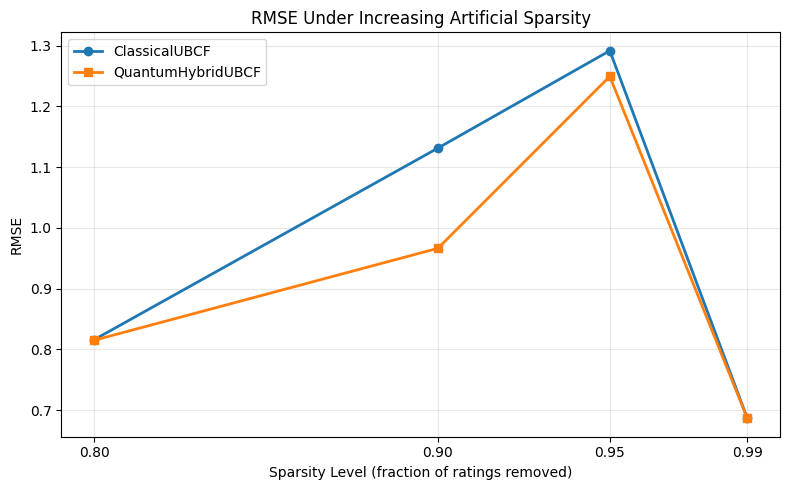

,sparsity_level,retained_fraction,rmse_classical,rmse_hybrid,hr10_classical,hr10_hybrid,rmse_delta_hybrid_minus_classical,hr10_delta_hybrid_minus_classical
0,0.80,0.20,0.815951,0.815071,0.16,0.16,-0.000881,0.00
1,0.90,0.10,1.131344,0.966452,0.00,0.08,-0.164893,0.08
2,0.95,0.05,1.291622,1.249442,0.00,0.00,-0.042180,0.00
3,0.99,0.01,0.686629,0.686629,0.00,0.00,0.000000,0.00


In [17]:
sparsity_results_df = run_sparsity_stress_test(
    user_item_matrix=user_item_matrix,
    classical_model_factory=lambda matrix: ClassicalUBCF(matrix),
    hybrid_model_factory=lambda matrix: QuantumHybridUBCF(matrix),
    evaluate_fn=evaluate_model,
    top_n_users=25,
)
sparsity_results_df

## Final Implementation — Synthetic Sparsity Degradation Curve (MovieLens)

This section explicitly simulates **80%, 90%, 95%, and 99% masking** of observed ratings and compares Classical vs Hybrid under each regime.

Goal: verify that the **QuantumHybridUBCF degradation is slower** than ClassicalUBCF as data becomes thinner.

Sparsity 80% | Classical RMSE=0.8160, HR@10=0.1600 | Hybrid RMSE=0.8151, HR@10=0.1600
Sparsity 90% | Classical RMSE=1.1313, HR@10=0.0000 | Hybrid RMSE=0.9665, HR@10=0.0800
Sparsity 95% | Classical RMSE=1.2916, HR@10=0.0000 | Hybrid RMSE=1.2494, HR@10=0.0000
Sparsity 99% | Classical RMSE=0.6866, HR@10=0.0000 | Hybrid RMSE=0.6866, HR@10=0.0000
Saved: sparsity_stress_test_results.csv
Saved: sparsity_stress_test_rmse.png


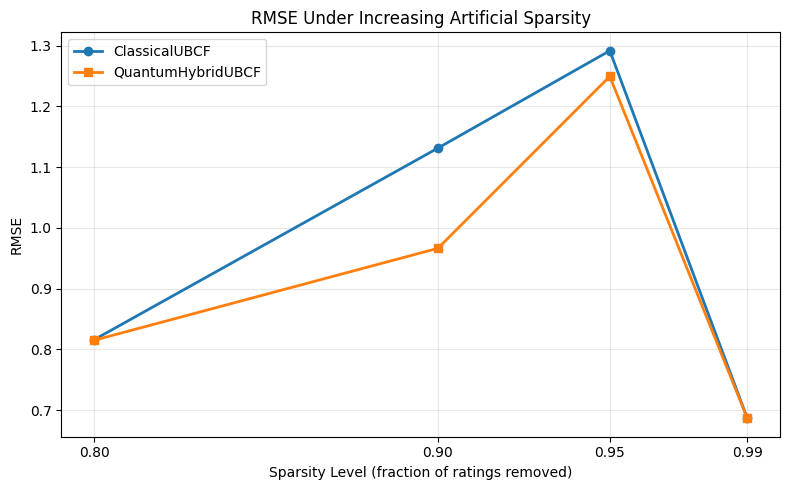

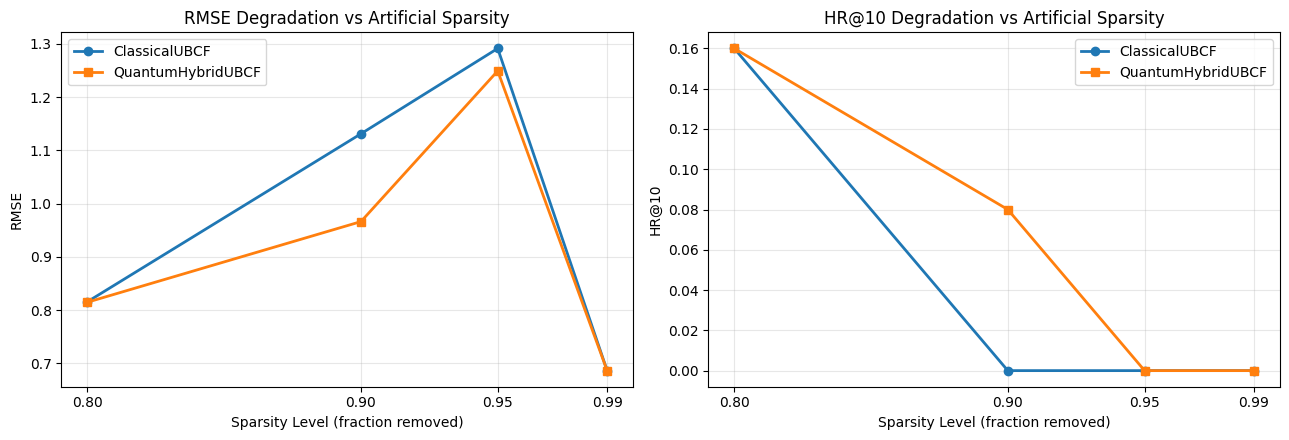

Saved: sparsity_degradation_curves_rmse_hr10.png
Saved: sparsity_degradation_summary.csv
Saved: sparsity_degradation_conclusion.csv

Conclusion metrics:
 mean_rmse_improvement_high_sparse  mean_hr10_improvement_high_sparse  hybrid_degrades_slower_rmse  hybrid_degrades_slower_hr10
                          0.069024                           0.026667                         True                         True


,sparsity_level,retained_fraction,rmse_classical,rmse_hybrid,hr10_classical,hr10_hybrid,rmse_delta_hybrid_minus_classical,hr10_delta_hybrid_minus_classical,rmse_growth_vs_80_classical_pct,rmse_growth_vs_80_hybrid_pct,hr_retention_vs_80_classical_pct,hr_retention_vs_80_hybrid_pct
0,0.80,0.20,0.815951,0.815071,0.16,0.16,-0.000881,0.00,0.000000,0.000000,99.999994,99.999994
1,0.90,0.10,1.131344,0.966452,0.00,0.08,-0.164893,0.08,38.653360,18.572738,0.000000,49.999997
2,0.95,0.05,1.291622,1.249442,0.00,0.00,-0.042180,0.00,58.296460,53.292500,0.000000,0.000000
3,0.99,0.01,0.686629,0.686629,0.00,0.00,0.000000,0.00,-15.849323,-15.758381,0.000000,0.000000


In [18]:
# Explicit synthetic sparsity loop + RMSE/HR@10 degradation curves
SPARSITY_LEVELS_SYNTH = [0.80, 0.90, 0.95, 0.99]

sparsity_results_df = run_sparsity_stress_test(
    user_item_matrix=user_item_matrix,
    classical_model_factory=lambda matrix: ClassicalUBCF(matrix),
    hybrid_model_factory=lambda matrix: QuantumHybridUBCF(matrix),
    evaluate_fn=evaluate_model,
    sparsity_levels=SPARSITY_LEVELS_SYNTH,
    top_n_users=25,
)

plot_df = sparsity_results_df.sort_values("sparsity_level").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# RMSE degradation
axes[0].plot(plot_df["sparsity_level"], plot_df["rmse_classical"], marker="o", linewidth=2, label="ClassicalUBCF")
axes[0].plot(plot_df["sparsity_level"], plot_df["rmse_hybrid"], marker="s", linewidth=2, label="QuantumHybridUBCF")
axes[0].set_title("RMSE Degradation vs Artificial Sparsity")
axes[0].set_xlabel("Sparsity Level (fraction removed)")
axes[0].set_ylabel("RMSE")
axes[0].set_xticks(SPARSITY_LEVELS_SYNTH)
axes[0].grid(alpha=0.3)
axes[0].legend()

# HR@10 degradation
axes[1].plot(plot_df["sparsity_level"], plot_df["hr10_classical"], marker="o", linewidth=2, label="ClassicalUBCF")
axes[1].plot(plot_df["sparsity_level"], plot_df["hr10_hybrid"], marker="s", linewidth=2, label="QuantumHybridUBCF")
axes[1].set_title("HR@10 Degradation vs Artificial Sparsity")
axes[1].set_xlabel("Sparsity Level (fraction removed)")
axes[1].set_ylabel("HR@10")
axes[1].set_xticks(SPARSITY_LEVELS_SYNTH)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "sparsity_degradation_curves_rmse_hr10.png", dpi=220, bbox_inches="tight")
plt.show()

# Summary statistics for report text
baseline_rmse_classical = float(plot_df.loc[plot_df["sparsity_level"] == 0.80, "rmse_classical"].iloc[0])
baseline_rmse_hybrid = float(plot_df.loc[plot_df["sparsity_level"] == 0.80, "rmse_hybrid"].iloc[0])

baseline_hr_classical = float(plot_df.loc[plot_df["sparsity_level"] == 0.80, "hr10_classical"].iloc[0])
baseline_hr_hybrid = float(plot_df.loc[plot_df["sparsity_level"] == 0.80, "hr10_hybrid"].iloc[0])

plot_df["rmse_growth_vs_80_classical_pct"] = 100.0 * (plot_df["rmse_classical"] - baseline_rmse_classical) / (baseline_rmse_classical + 1e-8)
plot_df["rmse_growth_vs_80_hybrid_pct"] = 100.0 * (plot_df["rmse_hybrid"] - baseline_rmse_hybrid) / (baseline_rmse_hybrid + 1e-8)

plot_df["hr_retention_vs_80_classical_pct"] = 100.0 * plot_df["hr10_classical"] / (baseline_hr_classical + 1e-8)
plot_df["hr_retention_vs_80_hybrid_pct"] = 100.0 * plot_df["hr10_hybrid"] / (baseline_hr_hybrid + 1e-8)

high_sparse = plot_df[plot_df["sparsity_level"] >= 0.90].copy()
mean_rmse_delta = float((high_sparse["rmse_classical"] - high_sparse["rmse_hybrid"]).mean())
mean_hr_delta = float((high_sparse["hr10_hybrid"] - high_sparse["hr10_classical"]).mean())

summary = {
    "mean_rmse_improvement_high_sparse": mean_rmse_delta,
    "mean_hr10_improvement_high_sparse": mean_hr_delta,
    "hybrid_degrades_slower_rmse": bool(mean_rmse_delta > 0),
    "hybrid_degrades_slower_hr10": bool(mean_hr_delta >= 0),
}

plot_df.to_csv(OUT_DIR / "sparsity_degradation_summary.csv", index=False)
pd.DataFrame([summary]).to_csv(OUT_DIR / "sparsity_degradation_conclusion.csv", index=False)

print("Saved: sparsity_degradation_curves_rmse_hr10.png")
print("Saved: sparsity_degradation_summary.csv")
print("Saved: sparsity_degradation_conclusion.csv")
print("\nConclusion metrics:")
print(pd.DataFrame([summary]).to_string(index=False))

display(plot_df)